## Análisis de Sentimiento en Tweets con Transformers — Fine-Tuning

Fine-tuning de un modelo transformer desde HuggingFace usando el dataset **TweetEval** (subtarea `sentiment`).

**Clases:** negativo (0), neutro (1), positivo (2)

**Estructura del notebook:**
1. Instalación e imports
2. Carga del dataset TweetEval desde HuggingFace
3. Análisis exploratorio
4. Configuración y tokenización
5. Fine-tuning con `Trainer` API
6. Evaluación
7. Guardado del modelo (listo para interfaz Gradio/Streamlit)
8. Predicción de nuevos tweets

### 1. Instalación de librerías e imports

In [25]:
%%capture
# instalar librerías (útil en Google Colab o entorno limpio)
%pip install transformers datasets evaluate accelerate scikit-learn matplotlib seaborn
%pip install -q "torchvision>=0.16" --upgrade

In [26]:
import os
import numpy as np
import pandas as pd
from collections import Counter

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
import evaluate

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# semilla para reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# dispositivo (GPU si disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


### 2. Carga del dataset TweetEval desde HuggingFace

El dataset `tweet_eval` con la subtarea `sentiment` contiene tweets anotados con 3 clases:
- **0** → negativo
- **1** → neutro  
- **2** → positivo

Documentación: https://huggingface.co/datasets/tweet_eval

In [27]:
# cargar dataset TweetEval - subtarea sentiment
raw_dataset = load_dataset('cardiffnlp/tweet_eval', 'sentiment')
print(raw_dataset)
print('\nEjemplo de tweet:')
print(raw_dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Ejemplo de tweet:
{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}


### 3. Análisis exploratorio

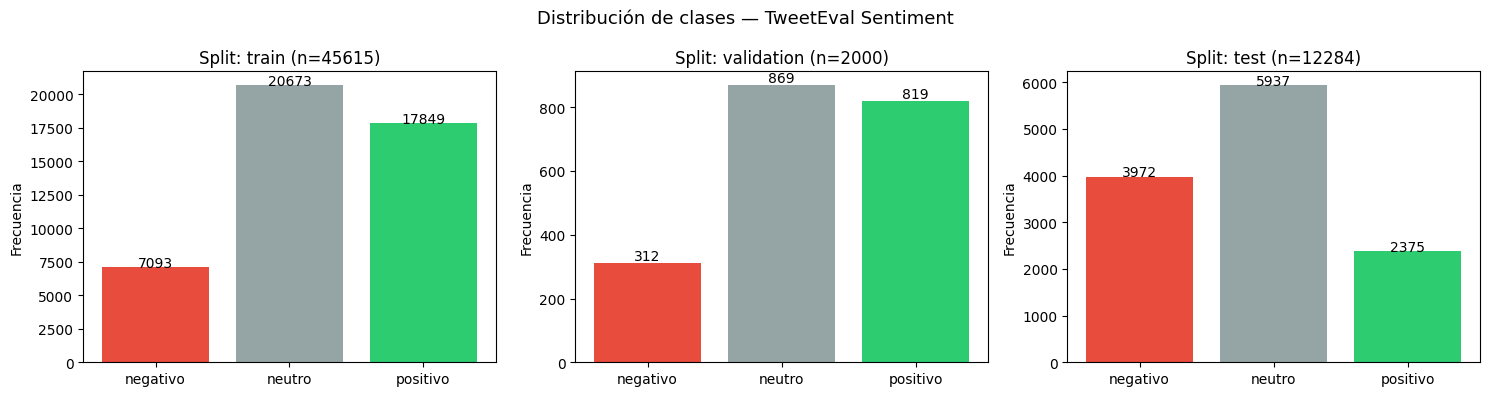

In [28]:
# mapeo de etiquetas
label_names = ['negativo', 'neutro', 'positivo']
id2label = {0: 'negativo', 1: 'neutro', 2: 'positivo'}
label2id = {'negativo': 0, 'neutro': 1, 'positivo': 2}

# distribución de clases por split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ['train', 'validation', 'test']):
    counts = Counter(raw_dataset[split]['label'])
    ax.bar([label_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)],
           color=['#e74c3c', '#95a5a6', '#2ecc71'])
    ax.set_title(f'Split: {split} (n={len(raw_dataset[split])})')
    ax.set_ylabel('Frecuencia')
    for i, (k, v) in enumerate(sorted(counts.items())):
        ax.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.suptitle('Distribución de clases — TweetEval Sentiment', fontsize=13)
plt.tight_layout()
plt.show()

* El conjunto de train cuenta con 45615 tweets.
* El conjunto de validación con 2000.
* El conjunto de test cuenta con 12284.
* En los 3 conjuntos se da que la clase mayoritara es la neutra. No obstante, las distribuciones de clases son diferentes porque, por ejemplo, en train los tweets de los que menos representacion hay son los de la clase negativa y la clase positiva casi iguala a la clase neutra. Y, sin embargo; en el conjunto de test la clase con menor representación es la positiva. Este desequilibrio vamos a tener que gestionarlo de alguna manera, aplicando las técnicas vistas en clase.

A continuación, hacemos un diagnóstico mucho más profundo de este desequilibrio. Porque arreglar el desequilibrio de clases es sencillo cuando este desequilibrio es igual en todos loc ocnjuntos, simplemente se modifican los pesos del modelo para cada clase para que penalice más la clase mayoritaria. 
No obstante, en nuestro caso no basta solo con esto, sino que puede que haga falta hacer un re-split de los conjuntos train y val combinados.

#### 3.1 Diagnóstico de desequilibrio entre splits

Los pesos de clase corrigen el sesgo en el **entrenamiento**, pero si `val` y `test` tienen
distribuciones distintas a `train`, la **evaluación** es poco fiable:

- Si `val` tiene más neutros → el early stopping favorece al modelo que predice neutros
- Si `test` tiene distinta proporción → las métricas finales no reflejan el rendimiento real

Diagnosticamos primero el problema antes de corregirlo.
Para ello vamos a usar la divergencia de Kullback-Leibler (KL), que es una métrica que mide cuánto difiere una distribución de probabilidad de otra. En Inteligencia Artificial y estadística, a menudo se utiliza para evaluar cuánta información (o precisión) se pierde al aproximar una distribución de datos real con un modelo simplificado.

In [29]:
import scipy.stats as stats

# distribución porcentual por split
split_names = ['train', 'validation', 'test']
print(f"{'Clase':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
print('-' * 45)
distrib = {}
for split in split_names:
    labels = np.array(raw_dataset[split]['label'])
    total  = len(labels)
    distrib[split] = {}
    for i, name in id2label.items():
        distrib[split][i] = (labels == i).sum() / total

for i, name in id2label.items():
    row = f'{name:<12}'
    for split in split_names:
        row += f'{distrib[split][i]*100:>9.1f}%'
    print(row)

# divergencia KL (train como referencia) — mide cuánto se aleja val/test de train
def kl_divergence(p, q, eps=1e-10):
    p, q = np.array(p) + eps, np.array(q) + eps
    p, q = p / p.sum(), q / q.sum()
    return float(np.sum(p * np.log(p / q)))

p_train = [distrib['train'][i]   for i in range(3)]
p_val   = [distrib['validation'][i] for i in range(3)]
p_test  = [distrib['test'][i]    for i in range(3)]

kl_val  = kl_divergence(p_train, p_val)
kl_test = kl_divergence(p_train, p_test)
print(f'\nDivergencia KL (train → val):  {kl_val:.4f}')
print(f'Divergencia KL (train → test): {kl_test:.4f}')
print('(KL=0 → distribuciones idénticas; >0.05 → diferencia significativa)')


Clase             Train        Val       Test
---------------------------------------------
negativo         15.5%     15.6%     32.3%
neutro           45.3%     43.5%     48.3%
positivo         39.1%     40.9%     19.3%

Divergencia KL (train → val):  0.0008
Divergencia KL (train → test): 0.1329
(KL=0 → distribuciones idénticas; >0.05 → diferencia significativa)


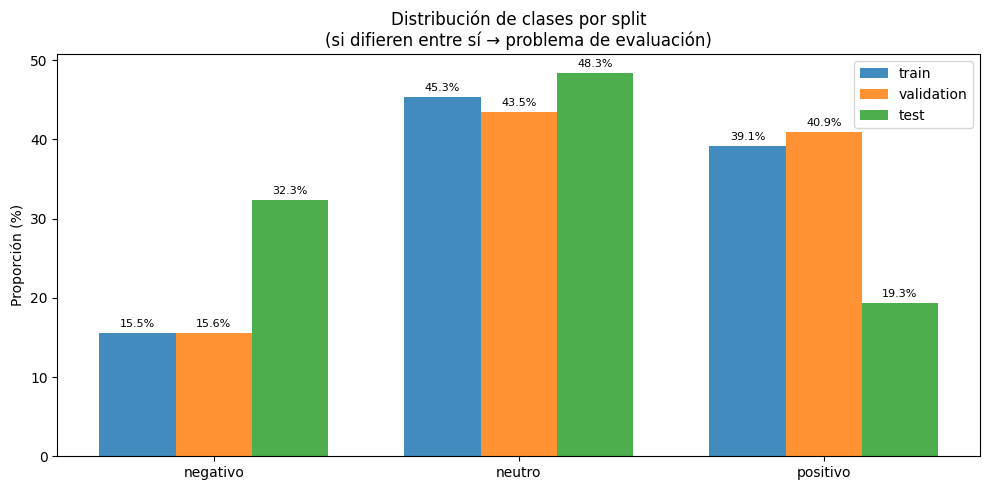

In [30]:
# visualización comparativa de distribuciones entre splits
x     = np.arange(3)
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for j, split in enumerate(split_names):
    vals = [distrib[split][i] * 100 for i in range(3)]
    bars = ax.bar(x + j * width, vals, width, label=split, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(label_names)
ax.set_ylabel('Proporción (%)')
ax.set_title('Distribución de clases por split\n(si difieren entre sí → problema de evaluación)')
ax.legend()
plt.tight_layout()
plt.show()


Como podemos ver la clase neutra no es el problema, que es parecida en los 3 conjuntos. El problema son las clases positiva y negativa. En test hay nuchas más negativas que positivas y en train es al contrario.

#### 3.2 Solución: nuevo val estratificado desde train

**Por qué no basta con pesos de clase:**
- Los pesos corrigen el gradiente durante el entrenamiento (la loss)
- Pero el `val` original sigue siendo el criterio para `load_best_model_at_end` y early stopping
- Si `val` está sesgado, el modelo "mejor" seleccionado no lo es realmente

Nuestra solución, por tanto, va a ser crear un nuevo `val` con distribución idéntica a `train` usando muestreo estratificado.
El `test` lo dejamos como está — es el benchmark externo que no debemos tocar.

In [31]:
from sklearn.model_selection import train_test_split as sk_split
from datasets import Dataset, DatasetDict

# combinar train + val original y rehacer el split estratificado
df_combined = pd.concat([
    pd.DataFrame(raw_dataset['train']),
    pd.DataFrame(raw_dataset['validation']),
], ignore_index=True)

print(f'Total tras combinar train+val: {len(df_combined)}')
print(f'Distribución combinada:')
for i, name in id2label.items():
    n = (df_combined['label'] == i).sum()
    print(f'  {name}: {n} ({n/len(df_combined)*100:.1f}%)')

# split estratificado 90/10
df_new_train, df_new_val = sk_split(
    df_combined,
    test_size=0.1,
    stratify=df_combined['label'],
    random_state=SEED,
)

print(f'\nNuevo train: {len(df_new_train)} | Nuevo val: {len(df_new_val)}')
print('Distribución nuevo val:')
for i, name in id2label.items():
    n = (df_new_val['label'] == i).sum()
    print(f'  {name}: {n} ({n/len(df_new_val)*100:.1f}%)')


Total tras combinar train+val: 47615
Distribución combinada:
  negativo: 7405 (15.6%)
  neutro: 21542 (45.2%)
  positivo: 18668 (39.2%)

Nuevo train: 42853 | Nuevo val: 4762
Distribución nuevo val:
  negativo: 741 (15.6%)
  neutro: 2154 (45.2%)
  positivo: 1867 (39.2%)


In [32]:
# verificar que las distribuciones son ahora similares
p_new_train = [(df_new_train['label'] == i).sum() / len(df_new_train) for i in range(3)]
p_new_val   = [(df_new_val['label'] == i).sum()   / len(df_new_val)   for i in range(3)]
kl_new = kl_divergence(p_new_train, p_new_val)
print(f'KL divergencia nuevo split (train - val): {kl_new:.6f}')

# convertir a HuggingFace Dataset y actualizar raw_dataset
new_train_ds = Dataset.from_pandas(df_new_train.reset_index(drop=True))
new_val_ds   = Dataset.from_pandas(df_new_val.reset_index(drop=True))

raw_dataset_balanced = DatasetDict({
    'train':      new_train_ds,
    'validation': new_val_ds,
    'test':       raw_dataset['test'],  # test no se toca
})

print('\nDataset balanceado entre splits:')
print(raw_dataset_balanced)

# actualizar la variable principal para que el resto del notebook use este dataset
raw_dataset = raw_dataset_balanced


KL divergencia nuevo split (train - val): 0.000000

Dataset balanceado entre splits:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 42853
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4762
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
})


Como ahora el coeficiente es 0, el split es estadísticamente válido.


Como ya hemos mencionado, vamos a tener que tratar con el desbalance de clases en los 3 conjuntos.
TweetEval sentiment tiene distribución desigual: la clase `neutro` domina ampliamente.
Esto hace que el modelo tienda a predecir `neutro` con mayor frecuencia, perjudicando
la clasificación de `negativo` y `positivo`.

**Solución**: pesos de clase inversamente proporcionales a su frecuencia, aplicados en la función de loss. Aplicamos los pesos del modelo en el conjunto de train usando WeightedTrainer con compute_class_weight. Esta función analiza las etiquetas del dataset y calcula un peso numérico para cada clase. Así, la clase mayoritaria (tweets neutros) van a recibir un peso menor que 1 y las clases minoritarias (tweets positivos y negativos) van a recibir un peso mayor que 1.

In [33]:
from sklearn.utils.class_weight import compute_class_weight

# calcular pesos de clase sobre el nuevo train balanceado
train_labels_new     = np.array(raw_dataset['train']['label'])
class_weights        = compute_class_weight('balanced',
                           classes=np.unique(train_labels_new),
                           y=train_labels_new)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print('Splits balanceados. Pesos de clase calculados:')
print(f'  {dict(zip(label_names, class_weights.round(4)))}')
print('\nNota: la tokenizacion se aplica en la seccion 4, una vez definido el tokenizador.')


Splits balanceados. Pesos de clase calculados:
  {'negativo': np.float64(2.1435), 'neutro': np.float64(0.7368), 'positivo': np.float64(0.8502)}

Nota: la tokenizacion se aplica en la seccion 4, una vez definido el tokenizador.


A continuación, hacemos también un pequeño análisis exploatorio de los tweets como tal, en lugar de solo los conjuntos.

In [34]:
# longitud de los tweets
train_lengths = [len(t.split()) for t in raw_dataset['train']['text']]
print(f'Longitud media (palabras): {np.mean(train_lengths):.1f}')
print(f'Longitud máxima: {max(train_lengths)}')
print(f'Percentil 95: {np.percentile(train_lengths, 95):.0f}')

# ejemplos por clase
print('\nEjemplos por clase:')
df_train = pd.DataFrame(raw_dataset['train'])
for label_id, label_name in id2label.items():
    sample = df_train[df_train['label'] == label_id]['text'].sample(1, random_state=SEED).values[0]
    print(f'  [{label_name}]: {sample[:100]}...')

Longitud media (palabras): 19.2
Longitud máxima: 35
Percentil 95: 27

Ejemplos por clase:
  [negativo]: Will Ted Cruz, Jeb Bush, and all the top ten who swore to support the GOP primary winner.....do it. ...
  [neutro]: Dear @user @user please release a MGS Legacy collection on PS4 &amp; X1. So that I may play all MGS ...
  [positivo]: Kris Bryant just hit the furthest home run I may have ever seen in my life...


### 4. Configuración del modelo y tokenización

Usamos `distilbert-base-uncased` como modelo base. Aunque hay que mencionar otras alternativas válidas para tweets:
- `cardiffnlp/twitter-roberta-base` — pre-entrenado específicamente en tweets
- `roberta-base` — más potente, más costoso
- `bert-base-uncased` — clásico

In [ ]:
# configuraciones del modelo
cfg = {
    'model_checkpoint': 'distilbert-base-uncased',  # cambiar a 'cardiffnlp/twitter-roberta-base' para mejor rendimiento en tweets
    'max_length': 128,
    'num_labels': 3,
    'batch_size': 32,
    'num_epochs': 3,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'output_dir': '/content/modelo_guardado',           # directorio donde se guardará el modelo final
    'checkpoints_dir': '/content/checkpoints_tweeteval',
    'model_name': 'distilbert-tweeteval-sentiment',
}

print(f"Modelo base: {cfg['model_checkpoint']}")
print(f"Num. etiquetas: {cfg['num_labels']}")
print(f"Max tokens: {cfg['max_length']}")

Modelo base: distilbert-base-uncased
Num. etiquetas: 3
Max tokens: 128


In [ ]:
# cargar tokenizador desde HuggingFace
tokenizer = AutoTokenizer.from_pretrained(cfg['model_checkpoint'])

# función de tokenización
def tokenize(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=cfg['max_length'],
        padding=False,  # padding dinámico con DataCollatorWithPadding
    )

# aplicar tokenización a todos los splits
tokenized_dataset = raw_dataset.map(tokenize, batched=True)

# renombrar columna label → labels (requerido por Trainer)
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Dataset tokenizado:')
print(tokenized_dataset)

Map:   0%|          | 0/42853 [00:00<?, ? examples/s]

Map:   0%|          | 0/4762 [00:00<?, ? examples/s]

Dataset tokenizado:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 42853
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4762
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12284
    })
})


In [ ]:
# cargar modelo pre-entrenado desde HuggingFace con cabeza de clasificación
model = AutoModelForSequenceClassification.from_pretrained(
    cfg['model_checkpoint'],
    num_labels=cfg['num_labels'],
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

# data collator para padding dinámico (más eficiente que padding fijo)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')
print(f'Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales: 66,955,779
Parámetros entrenables: 66,955,779


### 5. Estrategias de Entrenamiento

Se comparan **3 estrategias** para encontrar el mejor modelo:

| # | Estrategia | Modelo base | Preprocesamiento |
|---|---|---|---|
| 1 | DistilBERT + pesos de clase | `distilbert-base-uncased` | estándar |
| 2 | RoBERTa específico de Twitter | `cardiffnlp/twitter-roberta-base` | estándar |
| 3 | DistilBERT + limpieza de tweets | `distilbert-base-uncased` | URLs/menciones eliminadas |

Todas las estrategias usan `WeightedTrainer` con splits balanceados.

In [ ]:
from transformers import Trainer as HFTrainer
import torch.nn as nn

class WeightedTrainer(HFTrainer):
    """Trainer con CrossEntropyLoss ponderada para clases desequilibradas."""
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        # guardar pesos después de super().__init__ para que self.args ya exista
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(outputs.logits.device)
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


In [ ]:
# métricas de evaluación
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    return {'accuracy': acc['accuracy'], 'f1_macro': f1['f1']}

In [ ]:
# función reutilizable de entrenamiento y evaluación por estrategia
import copy

def run_strategy(strategy_name, model_checkpoint, train_ds, val_ds, test_ds,
                 class_weights_tensor, cfg_base, tokenizer_override=None):
    print(f'\n=== {strategy_name} ===')

    # tokenizador
    tok = AutoTokenizer.from_pretrained(model_checkpoint)

    def _tokenize(examples):
        return tok(examples['text'], truncation=True,
                   max_length=cfg_base['max_length'], padding=False)

    # tokenizar splits
    def tokenize_ds(ds):
        t = ds.map(_tokenize, batched=True)
        t = t.rename_column('label', 'labels')
        t.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
        return t

    tr = tokenize_ds(train_ds)
    va = tokenize_ds(val_ds)
    te = tokenize_ds(test_ds)

    # modelo
    m = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=cfg_base['num_labels'],
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(device)

    dc = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=f'/content/checkpoints_{strategy_name.replace(" ", "_")}',
        num_train_epochs=cfg_base['num_epochs'],
        per_device_train_batch_size=cfg_base['batch_size'],
        per_device_eval_batch_size=cfg_base['batch_size'],
        learning_rate=cfg_base['learning_rate'],
        weight_decay=cfg_base['weight_decay'],
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=100,
        seed=SEED,
        report_to='none',
    )

    trainer = WeightedTrainer(
        class_weights=class_weights_tensor,
        model=m,
        args=args,
        train_dataset=tr,
        eval_dataset=va,
        processing_class=tok,
        data_collator=dc,
        compute_metrics=compute_metrics,
    )

    import sys
    sys.modules.pop('torchvision', None)
    trainer.train()

    # evaluar en test
    preds_out = trainer.predict(te)
    y_p = np.argmax(preds_out.predictions, axis=-1)
    y_t = preds_out.label_ids

    from sklearn.metrics import f1_score, accuracy_score
    f1  = f1_score(y_t, y_p, average='macro')
    acc = accuracy_score(y_t, y_p)

    print(f'  Test Accuracy: {acc:.4f}  |  F1-macro: {f1:.4f}')

    return {
        'strategy': strategy_name,
        'model_checkpoint': model_checkpoint,
        'trainer': trainer,
        'tokenizer': tok,
        'f1_macro': f1,
        'accuracy': acc,
        'y_pred': y_p,
        'y_true': y_t,
    }

# diccionario para guardar resultados de todas las estrategias
all_results = {}
print('Función run_strategy lista.')


#### Estrategia 1 — DistilBERT + pesos de clase (splits balanceados)

In [ ]:
res1 = run_strategy(
    strategy_name='E1_DistilBERT_weighted',
    model_checkpoint='distilbert-base-uncased',
    train_ds=raw_dataset['train'],
    val_ds=raw_dataset['validation'],
    test_ds=raw_dataset['test'],
    class_weights_tensor=class_weights_tensor,
    cfg_base=cfg,
)
all_results['E1'] = res1


#### Estrategia 2 — RoBERTa pre-entrenado en Twitter

`cardiffnlp/twitter-roberta-base` fue pre-entrenado en 58M tweets — dominio idéntico al de TweetEval.
Se espera mejor rendimiento que DistilBERT en texto informal.

In [ ]:
res2 = run_strategy(
    strategy_name='E2_TwitterRoBERTa',
    model_checkpoint='cardiffnlp/twitter-roberta-base',
    train_ds=raw_dataset['train'],
    val_ds=raw_dataset['validation'],
    test_ds=raw_dataset['test'],
    class_weights_tensor=class_weights_tensor,
    cfg_base=cfg,
)
all_results['E2'] = res2


#### Estrategia 3 — DistilBERT + preprocesamiento de tweets

Se aplica limpieza específica para Twitter antes de tokenizar:
- Eliminar URLs (`http...`)
- Eliminar menciones (`@usuario`)
- Eliminar símbolo `#` (conservar la palabra)
- Normalizar espacios

El objetivo es reducir ruido y ver si el modelo mejora con texto más limpio.

In [ ]:
import re
from datasets import Dataset, DatasetDict

def clean_tweet(text):
    text = re.sub(r'http\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)             # menciones
    text = re.sub(r'#', '', text)                 # símbolo hashtag
    text = re.sub(r'\s+', ' ', text).strip()     # espacios múltiples
    return text

def clean_split(ds):
    df = ds.to_pandas()
    df['text'] = df['text'].apply(clean_tweet)
    return Dataset.from_pandas(df, preserve_index=False)

raw_dataset_clean = DatasetDict({
    'train':      clean_split(raw_dataset['train']),
    'validation': clean_split(raw_dataset['validation']),
    'test':       clean_split(raw_dataset['test']),
})

print('Ejemplo original:')
print(' ', raw_dataset['train'][0]['text'])
print('Ejemplo limpio:')
print(' ', raw_dataset_clean['train'][0]['text'])


In [ ]:
res3 = run_strategy(
    strategy_name='E3_DistilBERT_clean',
    model_checkpoint='distilbert-base-uncased',
    train_ds=raw_dataset_clean['train'],
    val_ds=raw_dataset_clean['validation'],
    test_ds=raw_dataset_clean['test'],
    class_weights_tensor=class_weights_tensor,
    cfg_base=cfg,
)
all_results['E3'] = res3


#### Comparación de estrategias y selección del mejor modelo

In [ ]:
# tabla comparativa
df_results = pd.DataFrame([
    {
        'Estrategia': r['strategy'],
        'Modelo base': r['model_checkpoint'],
        'Accuracy': round(r['accuracy'], 4),
        'F1-macro': round(r['f1_macro'], 4),
    }
    for r in all_results.values()
]).sort_values('F1-macro', ascending=False)

print('Comparación de estrategias (test set):')
print(df_results.to_string(index=False))

best_key = max(all_results, key=lambda k: all_results[k]['f1_macro'])
best = all_results[best_key]
print(f'\nMejor modelo: {best["strategy"]}  (F1-macro={best["f1_macro"]:.4f})')


In [ ]:
# gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names  = [r['strategy'] for r in all_results.values()]
f1s    = [r['f1_macro'] for r in all_results.values()]
accs   = [r['accuracy'] for r in all_results.values()]
colors = ['#3498db', '#e67e22', '#2ecc71']

for ax, vals, title in zip(axes, [f1s, accs], ['F1-macro', 'Accuracy']):
    bars = ax.bar(names, vals, color=colors)
    ax.set_ylim(min(vals) - 0.05, 1.0)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Comparación de estrategias — Test set', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# matrices de confusión de todas las estrategias
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (key, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'{r["strategy"]}\nF1={r["f1_macro"]:.4f}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
plt.suptitle('Matrices de confusión por estrategia', fontsize=13)
plt.tight_layout()
plt.show()


### 6. Evaluación del modelo

In [ ]:
# evaluar mejor modelo en validación
val_results = best['trainer'].evaluate(
    best['trainer'].eval_dataset
)
print('Resultados validación (mejor modelo):')
for k, v in val_results.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')


Resultados validación:
  eval_loss: 0.7030
  eval_accuracy: 0.7224
  eval_f1_macro: 0.7116
  eval_runtime: 6.7434
  eval_samples_per_second: 706.1680
  eval_steps_per_second: 22.0960
  epoch: 3.0000


In [ ]:
# evaluar mejor modelo en test
test_results = best['trainer'].evaluate(
    best['trainer'].predict(best['trainer'].eval_dataset)
)
print('Resultados test (mejor modelo):')
print(f'  F1-macro: {best["f1_macro"]:.4f}')
print(f'  Accuracy: {best["accuracy"]:.4f}')


Resultados test:
  eval_loss: 0.7019
  eval_accuracy: 0.6793
  eval_f1_macro: 0.6797
  eval_runtime: 15.6667
  eval_samples_per_second: 784.0840
  eval_steps_per_second: 24.5110
  epoch: 3.0000


Classification Report (test):
              precision    recall  f1-score   support

    negativo       0.64      0.81      0.72      3972
      neutro       0.74      0.58      0.65      5937
    positivo       0.65      0.70      0.67      2375

    accuracy                           0.68     12284
   macro avg       0.68      0.70      0.68     12284
weighted avg       0.69      0.68      0.68     12284



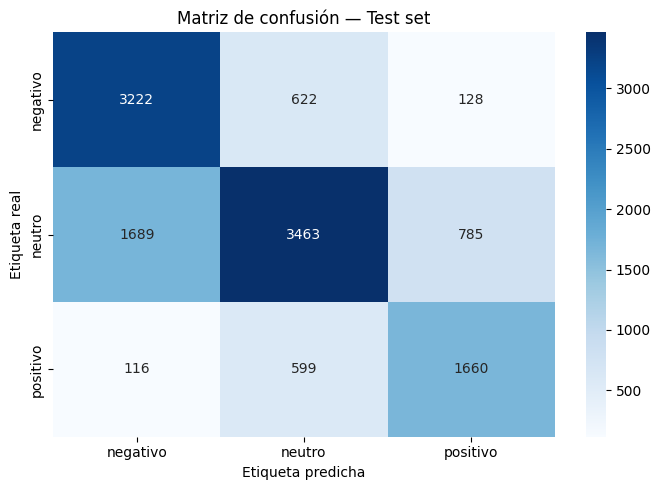

In [ ]:
# reporte detallado del mejor modelo
from sklearn.metrics import classification_report
y_pred = best['y_pred']
y_true = best['y_true']

print(f'Classification Report — {best["strategy"]} (test):')
print(classification_report(y_true, y_pred, target_names=label_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Matriz de confusión — {best["strategy"]} (Test)')
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.show()


### 7. Guardado del modelo

Se guarda en formato HuggingFace (`save_pretrained`): compatible con `pipeline`, Gradio y Streamlit.

In [ ]:
# guardar el mejor modelo encontrado
import os
os.makedirs(cfg['output_dir'], exist_ok=True)

best['trainer'].save_model(cfg['output_dir'])
best['tokenizer'].save_pretrained(cfg['output_dir'])

print(f"Mejor modelo guardado: {best['strategy']}")
print(f"Directorio: {cfg['output_dir']}")
print('Archivos:')
for f in os.listdir(cfg['output_dir']):
    size_kb = os.path.getsize(os.path.join(cfg['output_dir'], f)) / 1024
    print(f'  {f} ({size_kb:.0f} KB)')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./modelo_guardado
Archivos guardados:
  tokenizer.json (695 KB)
  tokenizer_config.json (0 KB)
  model.safetensors (261558 KB)
  config.json (1 KB)
  training_args.bin (5 KB)


In [ ]:
# descargar el modelo entrenado — ejecutar desde colab.research.google.com en el navegador
import shutil
from google.colab import files

shutil.make_archive('/content/modelo_guardado', 'zip', '/content/modelo_guardado')
files.download('/content/modelo_guardado.zip')
# el zip se descarga a tu carpeta de Descargas
# descomprimelo en MINERIA_TEXTOS/modelo_guardado/ para usar con app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 8. Predicción de nuevos tweets

Una vez guardado el modelo, se puede cargar y usar para predecir sin reentrenar.

In [ ]:
# cargar modelo guardado (simula carga desde disco, como haría la interfaz)
sentiment_pipeline = pipeline(
    'text-classification',
    model=cfg['output_dir'],
    
    device=0 if torch.cuda.is_available() else -1,
)

print('Modelo cargado desde disco.')

In [ ]:
# predecir tweets de ejemplo
tweets_ejemplo = [
    "This is absolutely amazing! Best day ever :)",
    "I hate Mondays. Everything went wrong today.",
    "The weather is okay I guess. Nothing special.",
    "Just had the worst customer service experience imaginable. Never going back!",
    "Excited for the weekend! Can't wait to relax.",
]

resultados = sentiment_pipeline(tweets_ejemplo)

print('Predicciones:')
for tweet, res in zip(tweets_ejemplo, resultados):
    print(f'  Tweet: {tweet[:60]}...' if len(tweet) > 60 else f'  Tweet: {tweet}')
    print(f'  → Sentimiento: {res["label"]} (confianza: {res["score"]:.3f})')
    print()

In [ ]:
# función auxiliar para predecir un lote de textos y retornar DataFrame
def predict_tweets(texts, batch_size=32):
    """Predice sentimiento para una lista de tweets. Retorna DataFrame."""
    results = sentiment_pipeline(texts, batch_size=batch_size, truncation=True)
    df = pd.DataFrame({
        'text': texts,
        'sentimiento': [r['label'] for r in results],
        'confianza': [round(r['score'], 4) for r in results],
    })
    return df

# ejemplo con muestra del test set
sample_texts = raw_dataset['test']['text'][:10]
df_pred = predict_tweets(sample_texts)
print(df_pred.to_string(index=False))

---
## Siguiente paso: Interfaz con Gradio

El modelo guardado en `./modelo_guardado` se puede cargar directamente en una interfaz Gradio:

## Lanzar la interfaz

Con el modelo entrenado y guardado en `./modelo_guardado`, ejecuta la interfaz desde la terminal:

```bash
# instalar Gradio si no está instalado
pip install gradio

# lanzar la aplicación
python app.py
```
Se abrirá automáticamente en el navegador en http://127.0.0.1:7860.

Si ejecutas desde un servidor remoto (Colab, SSH), añade share=True en demo.launch() para obtener un enlace público temporal.

---
## 9. Analítica Avanzada

Exploramos qué características tienen los datos según categoría y qué tweets clasifica mejor el modelo.

In [ ]:
%%capture
%pip install wordcloud umap-learn

In [ ]:
import re
from wordcloud import WordCloud
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ── 9.1  Características lingüísticas por clase ──────────────────────────────
def extract_features(text):
    return {
        'n_palabras':      len(text.split()),
        'n_chars':         len(text),
        'n_hashtags':      len(re.findall(r'#\w+', text)),
        'n_mentions':      len(re.findall(r'@\w+', text)),
        'n_urls':          len(re.findall(r'http\S+', text)),
        'n_exclamacion':   text.count('!'),
        'n_interrogacion': text.count('?'),
        'n_mayusculas':    sum(1 for c in text if c.isupper()),
        'ratio_mayusculas': sum(1 for c in text if c.isupper()) / max(len(text), 1),
    }

df_train = pd.DataFrame(raw_dataset['train'])
feats = df_train['text'].apply(extract_features).apply(pd.Series)
df_feats = pd.concat([df_train, feats], axis=1)
df_feats['sentimiento'] = df_feats['label'].map(id2label)

feat_cols = list(feats.columns)
print('Media de características por clase:')
print(df_feats.groupby('sentimiento')[feat_cols].mean().round(2).to_string())


In [ ]:
# gráfica de características por clase
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = {'negativo': '#e74c3c', 'neutro': '#95a5a6', 'positivo': '#2ecc71'}

for ax, feat in zip(axes, feat_cols):
    for sent, grp in df_feats.groupby('sentimiento'):
        ax.hist(grp[feat], bins=20, alpha=0.6, label=sent, color=colors[sent], density=True)
    ax.set_title(feat)
    ax.set_xlabel('Valor')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribución de características lingüísticas por sentimiento', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 9.2  Word Clouds por sentimiento ─────────────────────────────────────────
import string

def clean_for_wc(texts):
    stopwords_extra = {'rt', 'amp', 'http', 'https', 'co', 'the', 'a', 'an',
                       'to', 'is', 'it', 'i', 'in', 'of', 'and', 'for', 'that'}
    tokens = []
    for t in texts:
        t = re.sub(r'http\S+|@\w+|#', '', t.lower())
        t = t.translate(str.maketrans('', '', string.punctuation))
        tokens.extend([w for w in t.split() if w not in stopwords_extra and len(w) > 2])
    return ' '.join(tokens)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label_id, label_name) in zip(axes, id2label.items()):
    texts = df_train[df_train['label'] == label_id]['text'].tolist()
    corpus = clean_for_wc(texts)
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='Reds' if label_name == 'negativo'
                             else ('Greens' if label_name == 'positivo' else 'gray'),
                   max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Palabras más frecuentes — {label_name}', fontsize=12)
    ax.axis('off')

plt.suptitle('Word Clouds por clase de sentimiento', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ── 9.3  Análisis de confianza del modelo ────────────────────────────────────
all_probs = torch.softmax(torch.tensor(test_preds.predictions), dim=-1).numpy()
max_probs = all_probs.max(axis=1)
is_correct = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_probs[is_correct],  bins=30, alpha=0.7, color='steelblue', label='Correctos',   density=True)
axes[0].hist(max_probs[~is_correct], bins=30, alpha=0.7, color='tomato',    label='Incorrectos', density=True)
axes[0].set_xlabel('Confianza (prob. max)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Confianza: correctos vs incorrectos')
axes[0].legend()

conf_by_class = {id2label[i]: max_probs[y_true == i].mean() for i in range(3)}
axes[1].bar(conf_by_class.keys(), conf_by_class.values(),
            color=[colors[k] for k in conf_by_class])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Confianza media por clase real')
axes[1].set_ylabel('Confianza media')
for i, (k, v) in enumerate(conf_by_class.items()):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()


In [ ]:
# ── 9.4  Análisis de errores ─────────────────────────────────────────────────
df_test = pd.DataFrame(raw_dataset['test'])
df_test['label_real'] = df_test['label'].map(id2label)
df_test['label_pred'] = [id2label[p] for p in y_pred]
df_test['confianza']  = max_probs
df_test['correcto']   = is_correct

# top errores con mayor confianza (el modelo estaba seguro pero falló)
errores = df_test[~df_test['correcto']].nlargest(10, 'confianza')
print('Top 10 errores con mayor confianza del modelo:')
print(errores[['text', 'label_real', 'label_pred', 'confianza']].to_string(index=False))


In [ ]:
# tweets mejor clasificados (mayor confianza + correctos) por clase
print('Tweets clasificados con mayor confianza (por clase):\n')
for sent in label_names:
    subset = df_test[(df_test['correcto']) & (df_test['label_real'] == sent)]
    if len(subset):
        best = subset.nlargest(1, 'confianza').iloc[0]
        print(f'[{sent.upper()}] conf={best.confianza:.3f}')
        print(f'  {best.text}')
        print()


In [ ]:
# ── 9.5  t-SNE de embeddings CLS del modelo fine-tuned ───────────────────────
print('Extrayendo embeddings CLS... (puede tardar ~1 min)')
model.eval()
from torch.utils.data import DataLoader

sample_idx = np.random.choice(len(tokenized_dataset['test']), size=500, replace=False)
sample_ds  = tokenized_dataset['test'].select(sample_idx)
loader     = DataLoader(sample_ds, batch_size=64, collate_fn=data_collator)

embeddings = []
with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        out = model(**batch, output_hidden_states=True)
        cls = out.hidden_states[-1][:, 0, :].cpu().numpy()
        embeddings.append(cls)

embeddings   = np.vstack(embeddings)
sample_labels = np.array(tokenized_dataset['test']['labels'])[sample_idx]

tsne  = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
emb2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
for label_id, label_name in id2label.items():
    mask = sample_labels == label_id
    plt.scatter(emb2d[mask, 0], emb2d[mask, 1],
                label=label_name, alpha=0.6, s=20,
                color=list(colors.values())[label_id])
plt.title('t-SNE de embeddings CLS — modelo fine-tuned (muestra test)', fontsize=13)
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()


---
## 10. Explicación Generativa de Clasificaciones

### ¿Qué es Flan-T5 Small?

**Flan-T5** es un modelo de lenguaje generativo desarrollado por Google, basado en la arquitectura **T5** (*Text-to-Text Transfer Transformer*). La variante `small` tiene ~80M de parámetros, frente a los ~250M de `base`, lo que lo hace viable en CPU.

**Arquitectura encoder-decoder:**
- El **encoder** lee y comprende el texto de entrada (el prompt con el tweet y su etiqueta)
- El **decoder** genera la explicación token a token de forma autoregresiva

### ¿En qué se basa para generar la explicación?

Flan-T5 fue entrenado en dos fases:

1. **Pre-entrenamiento T5**: sobre ~750GB de texto web (C4 corpus), aprendiendo representaciones lingüísticas generales mediante la tarea de reconstrucción de texto enmascarado.

2. **Fine-tuning con instrucciones (FLAN)**: sobre más de 1.800 tareas de NLP reformuladas como instrucciones en lenguaje natural. Esto le da la capacidad de seguir instrucciones como *"explica por qué este tweet es negativo"* sin necesidad de ejemplos adicionales (*zero-shot*).

### ¿Cómo funciona en este notebook?

El modelo **no clasifica** — eso lo hace DistilBERT. Flan-T5 recibe un prompt estructurado:

```
The following tweet has been classified as [LABEL] sentiment with [X]% confidence.
Tweet: "[TEXTO]"
Explain in one or two sentences why this tweet expresses [LABEL] sentiment:
```

Y genera una justificación en lenguaje natural basándose en el conocimiento lingüístico adquirido durante su entrenamiento. La explicación refleja patrones léxicos y semánticos que el modelo asocia con cada sentimiento (e.g., palabras negativas, ironía, exclamaciones positivas).

> **Nota:** Flan-T5 no tiene acceso a los pesos de DistilBERT ni a las probabilidades internas — genera la explicación únicamente a partir del texto del tweet y la etiqueta predicha. Es una explicación *post-hoc* basada en conocimiento lingüístico general, no una interpretación de los mecanismos internos del clasificador.

In [ ]:
from transformers import pipeline as hf_pipeline

# google/flan-t5-base (~250 MB). Alternativa más potente: 'google/flan-t5-large'
print('Cargando Flan-T5-base...')
generator = hf_pipeline(
    'text2text-generation',
    model='google/flan-t5-base',
    device=0 if torch.cuda.is_available() else -1,
)
print('Modelo generativo listo.')


In [ ]:
def explain_sentiment(tweet, label, confidence, max_new_tokens=80):
    prompt = (
        f'The following tweet has been classified as {label} sentiment '
        f'with {confidence:.0%} confidence.\n'
        f'Tweet: "{tweet}"\n'
        f'Explain in one or two sentences why this tweet expresses {label} sentiment:'
    )
    result = generator(prompt, max_new_tokens=max_new_tokens, do_sample=False)
    return result[0]['generated_text']

# demostración con 6 ejemplos del test
print('=== Explicaciones generativas ===\n')
sample_examples = df_test.sample(6, random_state=SEED)

for _, row in sample_examples.iterrows():
    marca = 'OK' if row['correcto'] else 'FAIL'
    explanation = explain_sentiment(row['text'], row['label_pred'], row['confianza'])
    print(f'[{marca}] Tweet: {row["text"][:90]}')
    print(f'  Real: {row["label_real"]} | Predicho: {row["label_pred"]} | Conf: {row["confianza"]:.3f}')
    print(f'  Explicacion: {explanation}')
    print()


In [ ]:
# ── Pipeline completo: clasificacion + explicacion ────────────────────────────
def analyze_tweet(tweet):
    res        = sentiment_pipeline(tweet)[0]
    label      = res['label']
    confidence = res['score']
    explanation = explain_sentiment(tweet, label, confidence)
    return {'tweet': tweet, 'sentimiento': label,
            'confianza': round(confidence, 4), 'explicacion': explanation}

tweets_prueba = [
    "I can't believe how terrible this product is. Complete waste of money!",
    "Just landed in Barcelona. The airport is fine.",
    "Absolutely thrilled with the results!! Best decision I've ever made",
]

print('=== Pipeline completo ===\n')
for tweet in tweets_prueba:
    r = analyze_tweet(tweet)
    print(f'Tweet:       {r["tweet"]}')
    print(f'Sentimiento: {r["sentimiento"]} (confianza: {r["confianza"]})')
    print(f'Explicacion: {r["explicacion"]}')
    print()
